In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import train_test_split

In [71]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [72]:
class Model(nn.Module):
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [73]:
torch.manual_seed(42)
model = Model()

In [74]:
url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"

In [75]:
df = pd.read_csv(url)
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [76]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [77]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [78]:
# change species column to numerical values
df['species'] = df['species'].map({'setosa': 0.0, 'versicolor': 1.0, 'virginica': 2.0})

In [79]:
df['species'].unique()

array([0., 1., 2.])

In [80]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [ ]:
# split data into x and y, and convert to numpy arrays
x = df.drop('species', axis=1).values
y = df['species'].values

In [83]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [86]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [89]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [93]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [91]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (fc3): Linear(in_features=9, out_features=3, bias=True)
)>

In [95]:
epochs = 100
loss = []

for x in range(epochs):
    y_pred = model.forward(X_train)
    loss_value = criterion(y_pred, y_train)
    loss.append(loss_value.item())
    optimizer.zero_grad()
    loss_value.backward()
    optimizer.step()
    if (x+1) % 10 == 0:
        print(f'Epoch: {x+1}, Loss: {loss_value.item():.4f}')

Epoch: 10, Loss: 0.9305
Epoch: 20, Loss: 0.7718
Epoch: 30, Loss: 0.6257
Epoch: 40, Loss: 0.4598
Epoch: 50, Loss: 0.2870
Epoch: 60, Loss: 0.1696
Epoch: 70, Loss: 0.1029
Epoch: 80, Loss: 0.0707
Epoch: 90, Loss: 0.0548
Epoch: 100, Loss: 0.0460


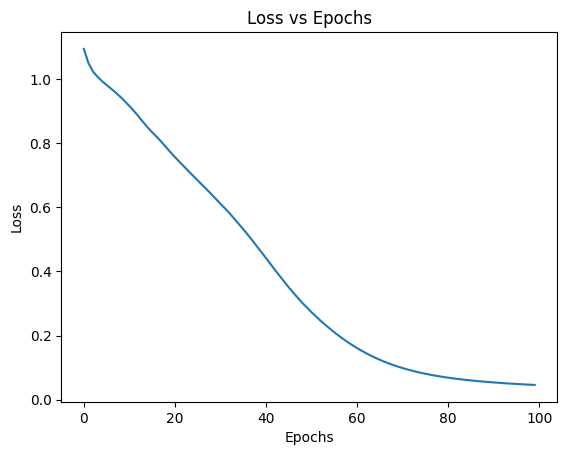

In [96]:
plt.plot(range(epochs), loss)
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.title('Loss vs Epochs')
plt.show()

In [98]:
with torch.no_grad():
    y_eval = model.forward(X_test)
    loss_value = criterion(y_eval, y_test)
    print(f'Test Loss: {loss_value.item():.4f}')

Test Loss: 0.1311


In [102]:
correct = 0
total = 0
with torch.no_grad():
    for i in range(len(y_test)):
        true_label = y_test[i]
        predicted_label = torch.argmax(y_eval[i])
        if true_label == predicted_label:
            correct += 1
        total += 1
accuracy = correct / total
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9333
